# Imbalanced Classes

## Overview

Class imbalance occurs when one class substantially outnumbers another (e.g. 95% negative, 5% positive). Standard classifiers optimise overall accuracy, which they achieve by over-predicting the majority class.

**Strategies (not mutually exclusive):**

| Strategy | Method | When to use |
|---|---|---|
| Algorithm-level | `class_weight="balanced"` | Always try first |
| Oversampling | SMOTE (synthetic minority) | Minority class too sparse |
| Undersampling | Random undersampling | Very large majority class |
| Threshold tuning | Choose threshold on PR curve | When FP/FN costs differ |
| Evaluation | Precision-Recall AUC, F1 | Always -- not just accuracy |

---

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, f1_score)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.special import expit

rng = np.random.default_rng(42)
n = 600
elevation  = rng.uniform(50, 400, n)
nitrate    = rng.gamma(2, 2, n)
ph         = rng.normal(7.2, 0.5, n)
# Construct labels with a controlled prevalence for teaching/demo purposes.
# Set target_prevalence to the desired positive class proportion (e.g. 0.01, 0.05, 0.10)
target_prevalence = 0.10
# Linear predictor (without intercept) - adjust coefficients to illustrate effects
linear_part = 0.003*elevation - 0.15*nitrate + 0.3*ph
# Find intercept that yields mean(probabilities) ~= target_prevalence via bisection
from math import isfinite
def _find_intercept(lp, target, lo=-50.0, hi=50.0, iters=60):
    # bisection on intercept so mean(expit(intercept + lp)) -> target
    for _ in range(iters):
        mid = 0.5*(lo+hi)
        p = expit(mid + lp).mean()
        if not isfinite(p):
            break
        if p > target:
            hi = mid
        else:
            lo = mid
    return 0.5*(lo+hi)
intercept = _find_intercept(linear_part, target_prevalence)
log_odds = intercept + linear_part
probs = expit(log_odds)
# Choose a deterministic threshold so the resulting labels match the target prevalence.
# Use the (1-target_prevalence) quantile of the probabilities as threshold.
thr = np.quantile(probs, 1 - target_prevalence)
label = (probs >= thr).astype(int)
print(f"Target prevalence: {target_prevalence:.3f}; threshold={thr:.4f}; achieved prevalence: {label.mean():.3f}")
print(f"Probabilities: min={probs.min():.3f}, mean={probs.mean():.3f}, max={probs.max():.3f}")
print(f"Class distribution: {np.bincount(label)} ({label.mean():.3f} positive)")
X = np.column_stack([elevation, nitrate, ph])
X_tr, X_te, y_tr, y_te = train_test_split(X, label, test_size=0.25,
                                            stratify=label, random_state=42)

Target prevalence: 0.100; threshold=0.1589; achieved prevalence: 0.100
Probabilities: min=0.009, mean=0.100, max=0.252
Class distribution: [540  60] (0.100 positive)


---
## The Problem: Accuracy is Misleading

In [8]:
# Baseline: always predict majority class
accuracy_naive = 1 - y_te.mean()
print(f"Naive (all-negative) accuracy: {accuracy_naive:.3f}")
# Standard RF without balancing
rf_std = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_std.fit(X_tr, y_tr)
print(f"\nStandard RF:")
pred_std = rf_std.predict(X_te)
print("Prediction distribution (pred_std):", np.bincount(pred_std))
classes_std = np.unique(np.concatenate([y_te, pred_std]))
if len(classes_std) == 2:
    print(classification_report(y_te, pred_std, target_names=["absent","present"]))
else:
    print("Only one class present:", classes_std)
    print(classification_report(y_te, pred_std))
probas_std = rf_std.predict_proba(X_te)
if probas_std.shape[1] > 1 and len(np.unique(y_te)) > 1:
    print(f"AUC-ROC: {roc_auc_score(y_te, probas_std[:,1]):.3f}")
else:
    print("AUC-ROC: undefined (only one class present in predictions or y_test)")

Naive (all-negative) accuracy: 0.900

Standard RF:
Prediction distribution (pred_std): [138  12]
              precision    recall  f1-score   support

      absent       0.98      1.00      0.99       135
     present       1.00      0.80      0.89        15

    accuracy                           0.98       150
   macro avg       0.99      0.90      0.94       150
weighted avg       0.98      0.98      0.98       150

AUC-ROC: 1.000


---
## class_weight="balanced"

In [9]:
rf_bal = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                 random_state=42, n_jobs=-1)
rf_bal.fit(X_tr, y_tr)
print("Balanced RF:")
pred_bal = rf_bal.predict(X_te)
print("Prediction distribution (pred_bal):", np.bincount(pred_bal))
classes_bal = np.unique(np.concatenate([y_te, pred_bal]))
if len(classes_bal) == 2:
    print(classification_report(y_te, pred_bal, target_names=["absent","present"]))
else:
    print("Only one class present:", classes_bal)
    print(classification_report(y_te, pred_bal))
probas_bal = rf_bal.predict_proba(X_te)
if probas_bal.shape[1] > 1 and len(np.unique(y_te)) > 1:
    print(f"AUC-ROC: {roc_auc_score(y_te, probas_bal[:,1]):.3f}")
else:
    print("AUC-ROC: undefined (only one class present in predictions or y_test)")

Balanced RF:
Prediction distribution (pred_bal): [138  12]
              precision    recall  f1-score   support

      absent       0.98      1.00      0.99       135
     present       1.00      0.80      0.89        15

    accuracy                           0.98       150
   macro avg       0.99      0.90      0.94       150
weighted avg       0.98      0.98      0.98       150

AUC-ROC: 0.998


---
## Precision-Recall Curve and Threshold Tuning

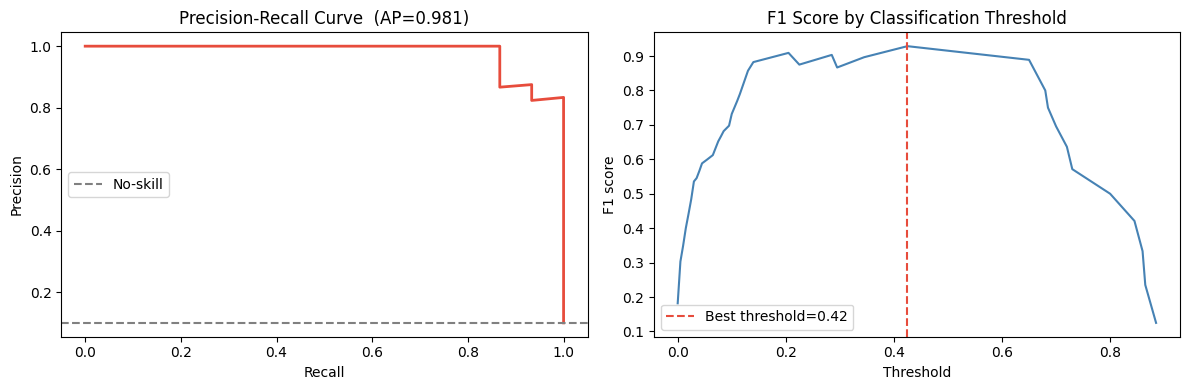

Best F1 threshold: 0.425
Prediction distribution (threshold): [137  13]
              precision    recall  f1-score   support

      absent       0.99      1.00      0.99       135
     present       1.00      0.87      0.93        15

    accuracy                           0.99       150
   macro avg       0.99      0.93      0.96       150
weighted avg       0.99      0.99      0.99       150



In [10]:
probas = rf_bal.predict_proba(X_te)
if probas.shape[1] > 1 and len(np.unique(y_te)) > 1:
    probs = probas[:,1]
    prec, rec, thresholds = precision_recall_curve(y_te, probs)
    ap = average_precision_score(y_te, probs)
    fig, axes = plt.subplots(1,2,figsize=(12,4))
    axes[0].plot(rec, prec, color="#e74c3c", lw=2)
    axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
    axes[0].set_title(f"Precision-Recall Curve  (AP={ap:.3f})")
    axes[0].axhline(y_te.mean(), color="grey", linestyle="--", label="No-skill")
    axes[0].legend()
    # F1 by threshold
    f1_scores = [f1_score(y_te, probs >= t) for t in thresholds]
    best_thresh = thresholds[np.argmax(f1_scores)]
    axes[1].plot(thresholds, f1_scores, color="steelblue", lw=1.5)
    axes[1].axvline(best_thresh, color="#e74c3c", lw=1.5, linestyle="--",
                    label=f"Best threshold={best_thresh:.2f}")
    axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("F1 score")
    axes[1].set_title("F1 Score by Classification Threshold")
    axes[1].legend(); plt.tight_layout(); plt.show()
    print(f"Best F1 threshold: {best_thresh:.3f}")
    pred_thresh = (probs >= best_thresh).astype(int)
    print("Prediction distribution (threshold):", np.bincount(pred_thresh))
    classes_thresh = np.unique(np.concatenate([y_te, pred_thresh]))
    if len(classes_thresh) == 2:
        print(classification_report(y_te, pred_thresh, target_names=["absent","present"]))
    else:
        print("Only one class present:", classes_thresh)
        print(classification_report(y_te, pred_thresh))
else:
    print("Precision-Recall and threshold tuning: undefined (only one class present in predictions or y_test)")

---
## SMOTE Oversampling

In [11]:
try:
    from imblearn.over_sampling import SMOTE
    if len(np.unique(y_tr)) > 1:
        sm = SMOTE(random_state=42)
        X_sm, y_sm = sm.fit_resample(X_tr, y_tr)
        print(f"After SMOTE: {np.bincount(y_sm)}")
        rf_sm = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        rf_sm.fit(X_sm, y_sm)
        probas_sm = rf_sm.predict_proba(X_te)
        if probas_sm.shape[1] > 1 and len(np.unique(y_te)) > 1:
            print(f"SMOTE RF AUC: {roc_auc_score(y_te, probas_sm[:,1]):.3f}")
        else:
            print("SMOTE RF AUC: undefined (only one class present in predictions or y_test)")
        pred_sm = rf_sm.predict(X_te)
        print("Prediction distribution (rf_sm):", np.bincount(pred_sm))
        classes_sm = np.unique(np.concatenate([y_te, pred_sm]))
        if len(classes_sm) == 2:
            print(classification_report(y_te, pred_sm, target_names=["absent","present"]))
        else:
            print("Only one class present:", classes_sm)
            print(classification_report(y_te, pred_sm))
    else:
        print("SMOTE skipped: training labels contain only one class:", np.unique(y_tr))
except ImportError:
    print("imbalanced-learn not installed: pip install imbalanced-learn")
    print("SMOTE creates synthetic minority samples by interpolating between nearest neighbours.")

After SMOTE: [405 405]
SMOTE RF AUC: 0.999
Prediction distribution (rf_sm): [134  16]
              precision    recall  f1-score   support

      absent       0.99      0.99      0.99       135
     present       0.88      0.93      0.90        15

    accuracy                           0.98       150
   macro avg       0.93      0.96      0.95       150
weighted avg       0.98      0.98      0.98       150



---

## Common Pitfalls

**1. Optimising for accuracy with imbalanced classes**  
A model predicting all-negative achieves 90% accuracy on a 10% positive dataset. Accuracy is meaningless for imbalanced outcomes. Always report precision, recall, F1, and PR-AUC for the minority class.

**2. Applying SMOTE before the train/test split**  
SMOTE generates synthetic points by interpolating between training examples. If applied before splitting, synthetic points derived from test-set neighbours leak test information into training. Always apply SMOTE inside a cross-validation fold or only to training data after splitting.

**3. Using ROC-AUC as the only metric for imbalanced data**  
ROC-AUC is insensitive to class imbalance because it evaluates performance across all possible thresholds including implausible ones. Precision-Recall AUC (average precision) is more informative for imbalanced outcomes.

**4. Not tuning the classification threshold**  
The default 0.5 threshold is rarely optimal for imbalanced classes. Choose the threshold using the Precision-Recall curve based on the relative cost of false positives and false negatives for the specific application.

**5. Over-relying on SMOTE without trying class_weight first**  
`class_weight="balanced"` is zero-cost, requires no resampling, and often matches SMOTE performance. Always try it first before adding the complexity of resampling approaches.


---
*python_methods_library - Samantha McGarrigle*